In [33]:
import rasterio as rio
import geopandas as gpd
import shapely
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

POINTS_FILE = "C:\\Users\\david\\dev\\geospatial-data-registration-toolkit\\data\\points_with_height.gpkg"
RASTER_FILE = "C:\\Users\\david\\dev\\geospatial-data-registration-toolkit\\data\\dtm-ptcloud_921.tif"

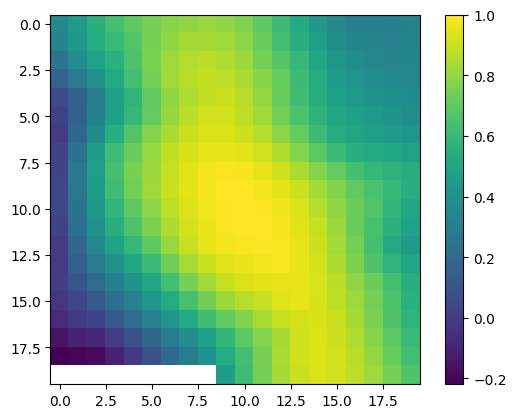

In [40]:
with rio.open(RASTER_FILE) as raster:
    # Read the points, ensuring they are in the same CRS as the raster
    sample_points = gpd.read_file(POINTS_FILE).to_crs(raster.crs)

    #sample_points.geometry = sample_points.translate(xoff=100, yoff=-50)

    # Extract the xy locations of the points
    xy_points = shapely.get_coordinates(sample_points.geometry)

    shifts = list(product(np.arange(-100, 100, 10), np.arange(-100, 100, 10)))

    provided_heights = sample_points["height"].values

    correlations = []

    for shift in shifts:

        shifted_xy_points = xy_points + np.expand_dims(shift, axis=0)
        # get the values from the raster
        sampled_heights = np.array(list(rio.sample.sample_gen(raster, shifted_xy_points))).squeeze()

        correlations.append(np.corrcoef(sampled_heights, provided_heights)[0,1])
correlations_img = np.reshape(correlations, (20,20))

plt.imshow(correlations_img)
plt.colorbar()